Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Input data hasil evaluasi dan konversi encoding ke label kelas

In [2]:
data = np.load("../model_evaluation_data.npz", allow_pickle=True)

X_val = data["X_val_final"]
y_val = data["y_val_final"]
y_pred = data["y_pred_final"]

y_true_classes = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

Proses confussion matrix

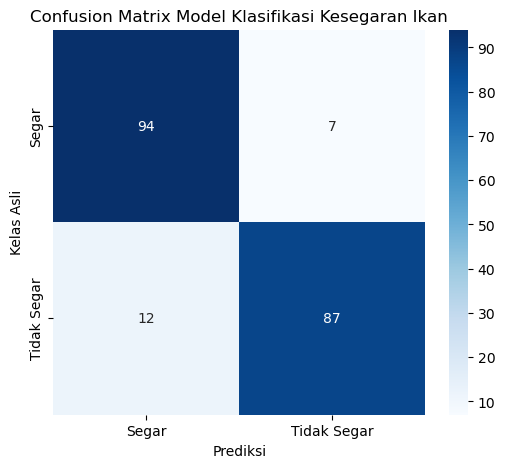

In [3]:
cm = confusion_matrix(y_true_classes, y_pred_classes)
class_names = ["Segar", "Tidak Segar"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix Model Klasifikasi Kesegaran Ikan")
plt.xlabel("Prediksi")
plt.ylabel("Kelas Asli")
plt.show()

Hasil output

In [4]:
report = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
print("📊 Classification Report:")
print(report)

📊 Classification Report:
              precision    recall  f1-score   support

       Segar       0.89      0.93      0.91       101
 Tidak Segar       0.93      0.88      0.90        99

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200



Percobaan Ulang

<Figure size 600x600 with 0 Axes>

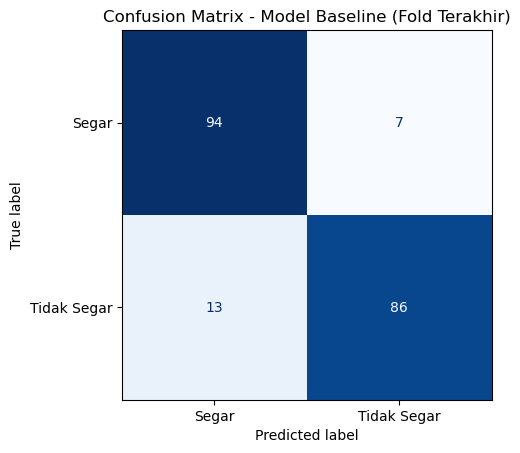


📊 Classification Report:
              precision    recall  f1-score  support
Segar          0.878505  0.930693  0.903846    101.0
Tidak Segar    0.924731  0.868687  0.895833     99.0
accuracy       0.900000  0.900000  0.900000      0.9
macro avg      0.901618  0.899690  0.899840    200.0
weighted avg   0.901387  0.900000  0.899880    200.0


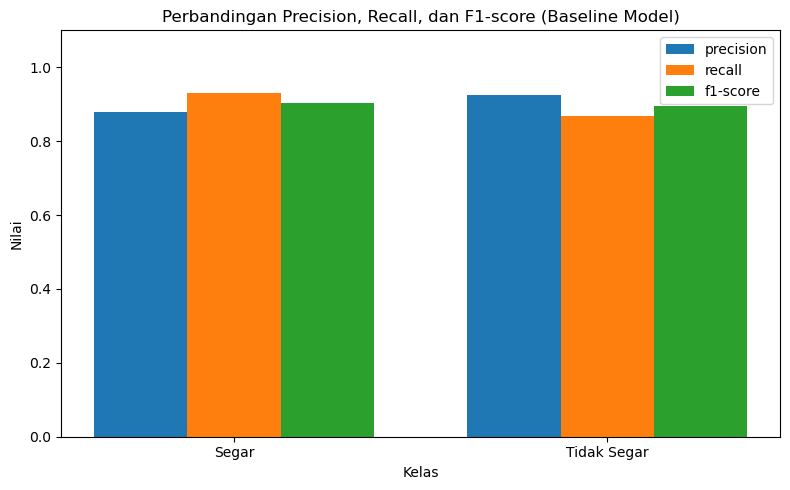


✅ Semua hasil evaluasi disimpan di: C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\base\evaluation


In [1]:
# === Evaluasi Model Baseline (K-Fold) ===

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# === Path utama hasil training ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\base"
eval_dir = os.path.join(base_dir, "evaluation")

# Pastikan folder evaluasi ada
os.makedirs(eval_dir, exist_ok=True)

# === 1. Muat data evaluasi yang disimpan ===
eval_data_path = os.path.join(eval_dir, "model_evaluation_data.npz")

if not os.path.exists(eval_data_path):
    raise FileNotFoundError(f"❌ File {eval_data_path} tidak ditemukan. Jalankan training terlebih dahulu.")

data = np.load(eval_data_path)
X_val_final = data["X_val_final"]
y_val_final = data["y_val_final"]
y_pred_final = data["y_pred_final"]

# === 2. Konversi Prediksi ke Label ===
y_true = np.argmax(y_val_final, axis=1)
y_pred = np.argmax(y_pred_final, axis=1)

# === 3. Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Segar", "Tidak Segar"])

plt.figure(figsize=(6, 6))
cm_display.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Model Baseline (Fold Terakhir)")
plt.savefig(os.path.join(eval_dir, "confusion_matrix_baseline.png"))
plt.show()

# === 4. Classification Report ===
report = classification_report(y_true, y_pred, target_names=["Segar", "Tidak Segar"], output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Simpan laporan ke CSV
report_path = os.path.join(eval_dir, "classification_report_baseline.csv")
report_df.to_csv(report_path)

print("\n📊 Classification Report:")
print(pd.DataFrame(report).transpose())

# === 5. Visualisasi Perbandingan Nilai Precision, Recall, F1-score ===
metrics = ["precision", "recall", "f1-score"]
class_names = ["Segar", "Tidak Segar"]

plt.figure(figsize=(8, 5))
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, [report_df.loc[c, metric] for c in class_names], width, label=metric)

plt.xlabel("Kelas")
plt.ylabel("Nilai")
plt.title("Perbandingan Precision, Recall, dan F1-score (Baseline Model)")
plt.xticks(x + width, class_names)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(eval_dir, "metrics_comparison_baseline.png"))
plt.show()

print(f"\n✅ Semua hasil evaluasi disimpan di: {eval_dir}")


evaluasi hasil pencarian hyperparameter tuning

In [2]:
import os

base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan"
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if "tuning" in file.lower() and file.endswith(".csv"):
            print(os.path.join(root, file))


C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\tuning_results.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load hasil tuning yang sebelumnya kamu simpan
tuning_results_path = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\tuning_results.csv"
df = pd.read_csv(tuning_results_path)

print("=== 5 Data Teratas dari Hasil Hyperparameter Tuning ===")
display(df.head())


=== 5 Data Teratas dari Hasil Hyperparameter Tuning ===


,learning_rate,dropout,batch_size,mean_accuracy,mean_loss
0,0.00010,0.3,16,92.299999,0.224949
1,0.00010,0.3,32,92.299999,0.242365
2,0.00010,0.5,16,92.299999,0.244366
3,0.00010,0.5,32,91.799999,0.276828
4,0.00005,0.3,16,90.500000,0.275798


In [6]:
print("Kolom yang tersedia di file CSV:")
print(df.columns.tolist())


Kolom yang tersedia di file CSV:
['learning_rate', 'dropout', 'batch_size', 'mean_accuracy', 'mean_loss']


=== 5 Kombinasi Hyperparameter Teratas Berdasarkan Akurasi ===


,learning_rate,dropout,batch_size,mean_accuracy,mean_loss
0,0.00010,0.3,16,92.299999,0.224949
1,0.00010,0.3,32,92.299999,0.242365
2,0.00010,0.5,16,92.299999,0.244366
3,0.00010,0.5,32,91.799999,0.276828
4,0.00005,0.3,16,90.500000,0.275798



=== Kombinasi Hyperparameter Terbaik ===
Learning Rate : 0.0001
Dropout       : 0.3
Batch Size    : 16.0
Mean Accuracy : 92.3000
Mean Loss     : 0.2249


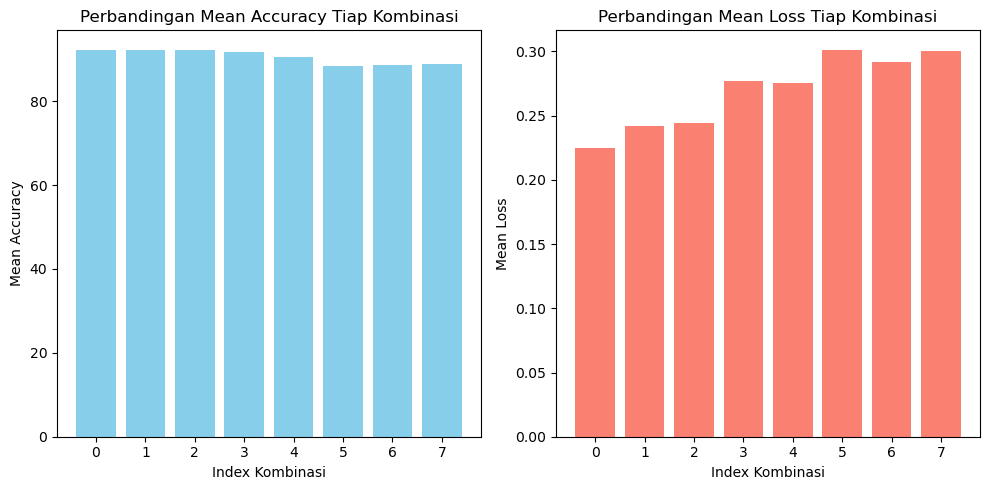


✅ Hasil evaluasi telah disimpan ke 'best_hyperparameter_results.csv'


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load hasil tuning ===
tuning_results_path = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\tuning_results.csv"
df = pd.read_csv(tuning_results_path)

# === 2. Tampilkan ringkasan data ===
print("=== 5 Kombinasi Hyperparameter Teratas Berdasarkan Akurasi ===")
best_models = df.sort_values(by='mean_accuracy', ascending=False)
display(best_models.head())

# === 3. Kombinasi terbaik ===
best_params = best_models.iloc[0]
print("\n=== Kombinasi Hyperparameter Terbaik ===")
print(f"Learning Rate : {best_params['learning_rate']}")
print(f"Dropout       : {best_params['dropout']}")
print(f"Batch Size    : {best_params['batch_size']}")
print(f"Mean Accuracy : {best_params['mean_accuracy']:.4f}")
print(f"Mean Loss     : {best_params['mean_loss']:.4f}")

# === 4. Visualisasi Akurasi dan Loss ===
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(df.index, df['mean_accuracy'], color='skyblue')
plt.title("Perbandingan Mean Accuracy Tiap Kombinasi")
plt.xlabel("Index Kombinasi")
plt.ylabel("Mean Accuracy")

plt.subplot(1,2,2)
plt.bar(df.index, df['mean_loss'], color='salmon')
plt.title("Perbandingan Mean Loss Tiap Kombinasi")
plt.xlabel("Index Kombinasi")
plt.ylabel("Mean Loss")

plt.tight_layout()
plt.show()

# === 5. Simpan hasil terbaik (opsional) ===
best_models.to_csv("best_hyperparameter_results.csv", index=False)
print("\n✅ Hasil evaluasi telah disimpan ke 'best_hyperparameter_results.csv'")


newwww

In [9]:
import os
import numpy as np
import cv2
from tensorflow.keras.utils import to_categorical

# === Folder Dataset ===
path_segar = r"C:\Users\Lenovo\Klasifikasi_ikan\datasets\normalized_output\segar"
path_tidak_segar = r"C:\Users\Lenovo\Klasifikasi_ikan\datasets\normalized_output\tidak_segar"

img_height, img_width = 224, 224

# === Fungsi untuk membaca dan resize citra ===
def load_images_from_folder(folder, label):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (img_width, img_height))
            img = img / 255.0  # Normalisasi [0–1]
            images.append(img)
            labels.append(label)
    return images, labels

# === Muat semua citra ===
images_segar, labels_segar = load_images_from_folder(path_segar, 0)  # Label 0 = Segar
images_tdk_segar, labels_tdk_segar = load_images_from_folder(path_tidak_segar, 1)  # Label 1 = Tidak Segar

# === Gabungkan data ===
X_data = np.array(images_segar + images_tdk_segar, dtype="float32")
y_data = np.array(labels_segar + labels_tdk_segar)

# === One-hot encoding label ===
y_data = to_categorical(y_data, num_classes=2)

print(f"✅ Dataset siap digunakan")
print(f"Total data: {len(X_data)}")
print(f"Shape X_data: {X_data.shape}")
print(f"Shape y_data: {y_data.shape}")

✅ Dataset siap digunakan
Total data: 1000
Shape X_data: (1000, 224, 224, 3)
Shape y_data: (1000, 2)


In [13]:
# === Evaluasi Model per Fold (K-Fold) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# === Path utama hasil training ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\base"
eval_dir = os.path.join(base_dir, "evaluation")

# === Parameter ===
k_folds = 5  # ubah jika fold kamu berbeda
class_names = ["Segar", "Tidak Segar"]

# === Loop setiap fold ===
for fold in range(1, k_folds + 1):
    fold_eval_dir = os.path.join(eval_dir, f"fold_{fold}")
    eval_data_path = os.path.join(fold_eval_dir, f"model_evaluation_data_fold{fold}.npz")

    if not os.path.exists(eval_data_path):
        print(f"⚠️ File evaluasi untuk Fold {fold} tidak ditemukan di {eval_data_path}")
        continue

    # === Lihat isi file ===
    data = np.load(eval_data_path)
    print(f"\n📂 Isi file {eval_data_path}: {list(data.keys())}")

    # === Deteksi otomatis key ===
    possible_y_true_keys = [k for k in data.keys() if "y_true" in k or "y_val" in k]
    possible_y_pred_keys = [k for k in data.keys() if "y_pred" in k]

    if not possible_y_true_keys or not possible_y_pred_keys:
        print(f"⚠️ Fold {fold} tidak memiliki key label/prediksi yang valid. Dilewati.")
        continue

    y_val_final = data[possible_y_true_keys[0]]
    y_pred_final = data[possible_y_pred_keys[0]]

    # === Konversi label one-hot ke indeks ===
    if y_val_final.ndim > 1:
        y_true = np.argmax(y_val_final, axis=1)
    else:
        y_true = y_val_final
    if y_pred_final.ndim > 1:
        y_pred = np.argmax(y_pred_final, axis=1)
    else:
        y_pred = y_pred_final

    # === Confusion Matrix ===
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()

    # Simpan Confusion Matrix
    cm_path = os.path.join(fold_eval_dir, f"confusion_matrix_fold{fold}.png")
    plt.savefig(cm_path)
    plt.close()

    # === Classification Report ===
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Simpan laporan ke CSV
    report_path = os.path.join(fold_eval_dir, f"classification_report_fold{fold}.csv")
    report_df.to_csv(report_path)

    # Cetak hasil ringkas ke console
    print(f"\n📊 Fold {fold} - Classification Report:")
    print(report_df)
    print("-" * 50)

print(f"\n✅ Semua confusion matrix dan laporan klasifikasi disimpan di: {eval_dir}")



📂 Isi file C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\base\evaluation\fold_1\model_evaluation_data_fold1.npz: ['y_true', 'y_pred']

📊 Fold 1 - Classification Report:
              precision    recall  f1-score  support
Segar          0.894231  0.968750      0.93    96.00
Tidak Segar    0.968750  0.894231      0.93   104.00
accuracy       0.930000  0.930000      0.93     0.93
macro avg      0.931490  0.931490      0.93   200.00
weighted avg   0.932981  0.930000      0.93   200.00
--------------------------------------------------

📂 Isi file C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\base\evaluation\fold_2\model_evaluation_data_fold2.npz: ['y_true', 'y_pred']

📊 Fold 2 - Classification Report:
              precision    recall  f1-score  support
Segar          0.926606  0.901786  0.914027  112.000
Tidak Segar    0.879121  0.909091  0.893855   88.000
accuracy       0.905000  0.905000  0.905000    0.905
macro avg      0.902863  0.905438  0.903941  200.000
weighted avg   0.905712  0.9

In [1]:
# === Evaluasi Model per Fold (K-Fold) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# === Path utama hasil training ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\base"
eval_dir = os.path.join(base_dir, "evaluation")

# === Parameter ===
k_folds = 5
class_names = ["Segar", "Tidak Segar"]

# Data penyimpanan ringkasan hasil per fold
summary_results = []

for fold in range(1, k_folds + 1):
    fold_eval_dir = os.path.join(eval_dir, f"fold_{fold}")
    eval_data_path = os.path.join(fold_eval_dir, f"model_evaluation_data_fold{fold}.npz")

    if not os.path.exists(eval_data_path):
        print(f"⚠️ File evaluasi untuk Fold {fold} tidak ditemukan")
        continue

    data = np.load(eval_data_path)

    # Deteksi key otomatis
    possible_y_true_keys = [k for k in data.keys() if "y_true" in k or "y_val" in k]
    possible_y_pred_keys = [k for k in data.keys() if "y_pred" in k]

    y_val_final = data[possible_y_true_keys[0]]
    y_pred_final = data[possible_y_pred_keys[0]]

    y_true = np.argmax(y_val_final, axis=1) if y_val_final.ndim > 1 else y_val_final
    y_pred = np.argmax(y_pred_final, axis=1) if y_pred_final.ndim > 1 else y_pred_final

    # === Confusion Matrix ===
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Hitung metrik manual
    acc = (tp + tn) / (tp + tn + fp + fn)
    pre = tp / (tp + fp) if (tp + fp) != 0 else 0
    rec = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = (2 * pre * rec / (pre + rec)) if (pre + rec) != 0 else 0

    # Simpan ke summary list
    summary_results.append([fold, tp, tn, fp, fn, acc, pre, rec, f1])

    # === Visualisasi dan save Confusion Matrix ===
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_eval_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

# === Simpan hasil ke CSV ===
columns = ["Fold", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1-Score"]
df_results = pd.DataFrame(summary_results, columns=columns)
df_results.loc["Rata-rata"] = df_results.mean(numeric_only=True)
df_results.to_csv(os.path.join(eval_dir, "rekapitulasi_kfold_performance.csv"), index=False)

print("\n✅ Rekapitulasi kinerja berhasil disimpan di:")
print(os.path.join(eval_dir, "rekapitulasi_kfold_performance.csv"))



✅ Rekapitulasi kinerja berhasil disimpan di:
C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\base\evaluation\rekapitulasi_kfold_performance.csv


In [2]:
import os
import numpy as np
import cv2
from tensorflow.keras.utils import to_categorical

# === Folder Dataset ===
path_segar = r"C:\Users\Lenovo\Klasifikasi_ikan\datasets\normalized_output\segar"
path_tidak_segar = r"C:\Users\Lenovo\Klasifikasi_ikan\datasets\normalized_output\tidak_segar"

img_height, img_width = 224, 224

# === Fungsi untuk membaca dan resize citra ===
def load_images_from_folder(folder, label):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (img_width, img_height))
            img = img / 255.0  # Normalisasi [0–1]
            images.append(img)
            labels.append(label)
    return images, labels

# === Muat semua citra ===
images_segar, labels_segar = load_images_from_folder(path_segar, 0)  # Label 0 = Segar
images_tdk_segar, labels_tdk_segar = load_images_from_folder(path_tidak_segar, 1)  # Label 1 = Tidak Segar

# === Gabungkan data ===
X_data = np.array(images_segar + images_tdk_segar, dtype="float32")
y_data = np.array(labels_segar + labels_tdk_segar)

# === One-hot encoding label ===
y_data = to_categorical(y_data, num_classes=2)

print(f"✅ Dataset siap digunakan")
print(f"Total data: {len(X_data)}")
print(f"Shape X_data: {X_data.shape}")
print(f"Shape y_data: {y_data.shape}")

✅ Dataset siap digunakan
Total data: 1000
Shape X_data: (1000, 224, 224, 3)
Shape y_data: (1000, 2)


LR_0.0001_DO_0.3_BS_16

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_0.0001_DO_0.3_BS_16"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1


7/7 [==============================] - 2s 135ms/step
              precision    recall  f1-score  support
Segar          0.929293  0.958333  0.943590   96.000
Tidak Segar    0.960396  0.932692  0.946341  104.000
accuracy       0.945000  0.945000  0.945000    0.945
macro avg      0.944844  0.945513  0.944966  200.000
weighted avg   0.945467  0.945000  0.945021  200.000

🔹 Evaluasi Fold 2
7/7 [==============================] - 1s 131ms/step
              precision    recall  f1-score  support
Segar          0.935185  0.901786  0.918182   112.00
Tidak Segar    0.880435  0.920455  0.900000    88.00
accuracy       0.910000  0.910000  0.910000     0.91
macro avg      0.907810  0.911120  0.909091   200.00
weighted avg   0.911095  0.910000  0.910182   200.00

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 129ms/step
              precision    recall  f1-score  support
Segar          0.969697  0.905660  0.936585  106.000
Tidak Segar    0.900990  0.968085  0.933

LR_0.0001_DO_0.3_BS_32

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_0.0001_DO_0.3_BS_32"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1
7/7 [==============================] - 1s 125ms/step
              precision    recall  f1-score  support
Segar          0.918367  0.937500  0.927835    96.00
Tidak Segar    0.941176  0.923077  0.932039   104.00
accuracy       0.930000  0.930000  0.930000     0.93
macro avg      0.929772  0.930288  0.929937   200.00
weighted avg   0.930228  0.930000  0.930021   200.00

🔹 Evaluasi Fold 2
7/7 [==============================] - 2s 126ms/step
              precision    recall  f1-score  support
Segar          0.941748  0.866071  0.902326  112.000
Tidak Segar    0.845361  0.931818  0.886486   88.000
accuracy       0.895000  0.895000  0.895000    0.895
macro avg      0.893554  0.898945  0.894406  200.000
weighted avg   0.899337  0.895000  0.895356  200.000

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 129ms/step
              precision    recall  f1-score  support
Segar          0.990099  0.943396  0.966184  106.000
Tidak Segar    0.939394  0.989362  0.96373

LR_0.0001_DO_0.5_BS_16

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_0.0001_DO_0.5_BS_16"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1


7/7 [==============================] - 2s 130ms/step
              precision    recall  f1-score  support
Segar          0.917526  0.927083  0.922280   96.000
Tidak Segar    0.932039  0.923077  0.927536  104.000
accuracy       0.925000  0.925000  0.925000    0.925
macro avg      0.924782  0.925080  0.924908  200.000
weighted avg   0.925073  0.925000  0.925013  200.000

🔹 Evaluasi Fold 2
7/7 [==============================] - 1s 126ms/step
              precision    recall  f1-score  support
Segar          0.935185  0.901786  0.918182   112.00
Tidak Segar    0.880435  0.920455  0.900000    88.00
accuracy       0.910000  0.910000  0.910000     0.91
macro avg      0.907810  0.911120  0.909091   200.00
weighted avg   0.911095  0.910000  0.910182   200.00

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 120ms/step
              precision    recall  f1-score  support
Segar          0.980198  0.933962  0.956522  106.000
Tidak Segar    0.929293  0.978723  0.953

LR_0.0001_DO_0.5_BS_32

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_0.0001_DO_0.5_BS_32"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1
7/7 [==============================] - 1s 121ms/step
              precision    recall  f1-score  support
Segar          0.910891  0.958333  0.934010   96.000
Tidak Segar    0.959596  0.913462  0.935961  104.000
accuracy       0.935000  0.935000  0.935000    0.935
macro avg      0.935244  0.935897  0.934985  200.000
weighted avg   0.936218  0.935000  0.935024  200.000

🔹 Evaluasi Fold 2
7/7 [==============================] - 1s 120ms/step
              precision    recall  f1-score  support
Segar          0.942308  0.875000  0.907407    112.0
Tidak Segar    0.854167  0.931818  0.891304     88.0
accuracy       0.900000  0.900000  0.900000      0.9
macro avg      0.898237  0.903409  0.899356    200.0
weighted avg   0.903526  0.900000  0.900322    200.0

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 119ms/step
              precision    recall  f1-score  support
Segar          0.979798  0.915094  0.946341  106.000
Tidak Segar    0.910891  0.978723  0.94359

LR_0.00005_DO_0.3_BS_16

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_5e-05_DO_0.3_BS_16"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1
7/7 [==============================] - 1s 120ms/step
              precision    recall  f1-score  support
Segar          0.916667  0.916667  0.916667    96.00
Tidak Segar    0.923077  0.923077  0.923077   104.00
accuracy       0.920000  0.920000  0.920000     0.92
macro avg      0.919872  0.919872  0.919872   200.00
weighted avg   0.920000  0.920000  0.920000   200.00

🔹 Evaluasi Fold 2
7/7 [==============================] - 1s 120ms/step
              precision    recall  f1-score  support
Segar          0.913462  0.848214  0.879630   112.00
Tidak Segar    0.822917  0.897727  0.858696    88.00
accuracy       0.870000  0.870000  0.870000     0.87
macro avg      0.868189  0.872971  0.869163   200.00
weighted avg   0.873622  0.870000  0.870419   200.00

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 123ms/step
              precision    recall  f1-score  support
Segar            0.9700  0.915094  0.941748   106.00
Tidak Segar      0.9100  0.968085  0.93814

LR_0.00005_DO_0.3_BS_32

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_5e-05_DO_0.3_BS_32"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1
7/7 [==============================] - 1s 128ms/step
              precision    recall  f1-score  support
Segar          0.908163  0.927083  0.917526    96.00
Tidak Segar    0.931373  0.913462  0.922330   104.00
accuracy       0.920000  0.920000  0.920000     0.92
macro avg      0.919768  0.920272  0.919928   200.00
weighted avg   0.920232  0.920000  0.920024   200.00

🔹 Evaluasi Fold 2
7/7 [==============================] - 1s 121ms/step
              precision    recall  f1-score  support
Segar          0.904762  0.848214  0.875576  112.000
Tidak Segar    0.821053  0.886364  0.852459   88.000
accuracy       0.865000  0.865000  0.865000    0.865
macro avg      0.862907  0.867289  0.864018  200.000
weighted avg   0.867930  0.865000  0.865405  200.000

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 131ms/step
              precision    recall  f1-score  support
Segar          0.948454  0.867925  0.906404  106.000
Tidak Segar    0.864078  0.946809  0.90355

LR_0.00005_DO_0.5_BS_16

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_5e-05_DO_0.5_BS_16"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1
7/7 [==============================] - 1s 121ms/step
              precision    recall  f1-score  support
Segar          0.909091  0.937500  0.923077   96.000
Tidak Segar    0.940594  0.913462  0.926829  104.000
accuracy       0.925000  0.925000  0.925000    0.925
macro avg      0.924842  0.925481  0.924953  200.000
weighted avg   0.925473  0.925000  0.925028  200.000

🔹 Evaluasi Fold 2
7/7 [==============================] - 1s 126ms/step
              precision    recall  f1-score  support
Segar          0.909091  0.803571  0.853081  112.000
Tidak Segar    0.782178  0.897727  0.835979   88.000
accuracy       0.845000  0.845000  0.845000    0.845
macro avg      0.845635  0.850649  0.844530  200.000
weighted avg   0.853249  0.845000  0.845556  200.000

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 121ms/step
              precision    recall  f1-score  support
Segar          0.958763  0.877358  0.916256  106.000
Tidak Segar    0.873786  0.957447  0.91370

LR_0.00005_DO_0.5_BS_16

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# === Load Dataset (harus menggunakan X_data & y_data dari kode datasetmu) ===
# Pastikan X_data dan y_data sudah ada di RAM
# y_data masih one-hot (categorical)
y_labels = np.argmax(y_data, axis=1)

# === Path model tuning ===
base_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\tuning\LR_5e-05_DO_0.5_BS_32"
eval_dir = os.path.join(base_dir, "evaluation")
os.makedirs(eval_dir, exist_ok=True)

k_folds = 5
class_names = ["Segar", "Tidak Segar"]

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in kf.split(X_data, y_labels):

    print(f"\n🔹 Evaluasi Fold {fold}")

    X_val = X_data[val_index]
    y_val = y_labels[val_index]

    # Load model sesuai fold
    model_path = os.path.join(base_dir, f"fold_{fold}.keras")
    model = load_model(model_path)

    # Prediksi
    y_pred = model.predict(X_val)
    y_pred = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_dir = os.path.join(eval_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f"confusion_matrix_fold{fold}.png"))
    plt.close()

    # Classification Report
    report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(fold_dir, f"classification_report_fold{fold}.csv"))

    print(report_df)
    fold += 1

print(f"\n✅ Semua evaluasi tersimpan di: {eval_dir}")



🔹 Evaluasi Fold 1
7/7 [==============================] - 1s 119ms/step
              precision    recall  f1-score  support
Segar          0.898990  0.927083  0.912821   96.000
Tidak Segar    0.930693  0.903846  0.917073  104.000
accuracy       0.915000  0.915000  0.915000    0.915
macro avg      0.914841  0.915465  0.914947  200.000
weighted avg   0.915476  0.915000  0.915032  200.000

🔹 Evaluasi Fold 2
7/7 [==============================] - 1s 119ms/step
              precision    recall  f1-score  support
Segar          0.927083  0.794643  0.855769   112.00
Tidak Segar    0.778846  0.920455  0.843750    88.00
accuracy       0.850000  0.850000  0.850000     0.85
macro avg      0.852965  0.857549  0.849760   200.00
weighted avg   0.861859  0.850000  0.850481   200.00

🔹 Evaluasi Fold 3
7/7 [==============================] - 1s 120ms/step
              precision    recall  f1-score  support
Segar          0.968421  0.867925  0.915423  106.000
Tidak Segar    0.866667  0.968085  0.91457